# Task 3.4 기본 양자회로 만들기

이 노트북은 양자회로를 어떻게 만드는지 다룹니다.

* **Quantum circuit architecture** Qiskit이 양자회로를 구현하는 객체(object)의 위계와 구성요소
* **Custom circuit elements** 어떻게 사용자 정의 "gate"와 "instruction"을 만드는가
* **Circuit compilation** 어떻게 abstract circuit을 physical circuit으로 바꾸는가
* **Circuit simulation**과 오류를 줄이는 기술들

In [1]:
# 필요 라이브러리 불러오기
import numpy as np
import math
from qiskit.circuit import Gate, QuantumCircuit, Parameter,CircuitInstruction,SessionEquivalenceLibrary
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit.circuit import pauli_twirl_2q_gates
from qiskit.quantum_info import Statevector
from qiskit.providers.basic_provider import BasicProvider
from qiskit import transpile
from qiskit.circuit.classical import expr
from qiskit.circuit import get_control_flow_name_mapping
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


print("라이브러리들을 불러왔습니다.")

라이브러리들을 불러왔습니다.


## Objective 1 : 양자회로의 기초

Qiskit의 양자회로에는 기본적으로 두 가지 종류가 있습니다:

- **Abstract circuit** : virtual qubit과 캡슐화된 알고리듬이나 사용자 정의 gate같은 상위 operation들로 정의됩니다. 실제 어떤 하드웨어가 사용되는지와는 무관하게 알고리듬적 논리에 중점을 둡니다.
- **Physical circuit** : 특정 하드웨어(백엔드/양자 컴퓨터)에서 실제로 구현된 qubit과 그 백엔드가 지원하는 operaion들만으로 정의됩니다. **ISA** (Instruction Set Architecture) circuit이라고도 합니다.

### 양자회로 API

양자회로의 구성요소의 위계는 다음과 같습니다:

- **Bit** : `Qubit` 또는 `Clbit`(classical bit)
- **Register** : bit들의 묶음. `QuantumRegister` 또는 `ClassicalRegister`
- **CircuitInstruction** : `Qubit` 또는 `Clbit`에 작용하는 `Operation`들로 구성됩니다.
- **Operation** :
  - `Instruction`: 하드웨어에 기반한 instruction
  - `Gate`: unitary instruction 또는 `ControlledGate`("control"을 가진 gate)
- **Instruction** : `Barrier`, `Delay`, `Measure`, `Reset`, `Store`, `ControlFlowOp`
- **ControlFlowOp** : `BreakLoopOp`, `ContinueLoopOp`, `BoxOp`, `ForLoopOp`, `IfElseOp`, `SwitchCaseOp`, `WhileLoopOp`

회로는 실시간으로 계산된 classical 표현(expression)들을 포함할수 있습니다:

- **Var**: 타입을 가진 classical 값의 회로상 저장 위치
- **Expr**: 실시간으로 계산된 표현
- **Type**: 표현의 classical 타입

이전 노트북에서 설명된 매개변수 class들도 사용할수 있습니다:

- **Parameter**: compile-time 표현의 최소 구성요소
- **ParameterExpression**: 매개변수들을 사용한 기호연산
- **ParameterVector**: 여러 매개변수들의 묶음
- **ParameterVectorElement**: `ParameterVector`의 item들을 나타내기 위한 `Parameter`의 subclass

컴파일을 돕는 class들도 있습니다:

- **EquivalenceLibrary** : 회로와 그를 구성하는 gate들의 관계의 database
- **SessionEquivalenceLibrary** : `EquivalenceLibrary` class의 가변 instance

무작위 회로를 만들어주는 유틸과 `CircuitError` exception class도 있습니다:

-`random.random_circuit()`
-`random.random_circuit_from_graph()`
-`random.random_clifford_circuit()`


In [2]:
# 사용자 정의 Gate의 예

class EntanglmentGate(Gate):
    def __init__(self):
        # 이름, qubit 수, 매개변수들로 초기화
        super().__init__("ent", 2, [])
 
    def _define(self):
        # H gate와 CX gate를 적용하는 것으로 정의
        defn = QuantumCircuit(2)
        defn.h(0)
        defn.cx(0,1)
        self._definition = defn

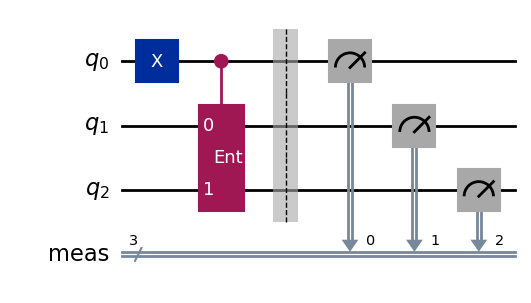

In [3]:
# control qubit을 가진 gate를 사용하는 예

num_qubits = 3
gate = EntanglmentGate()
qc = QuantumCircuit(num_qubits)
qc.x(0)
# gate에 하나의 control bit을 더함
gate = gate.control(1)
# 이 gate를 qc 회로에 더함
qc.append(gate,range(num_qubits),[])
qc.measure_all()
qc.draw('mpl')

Measurement Output: {'111': 495, '001': 505}


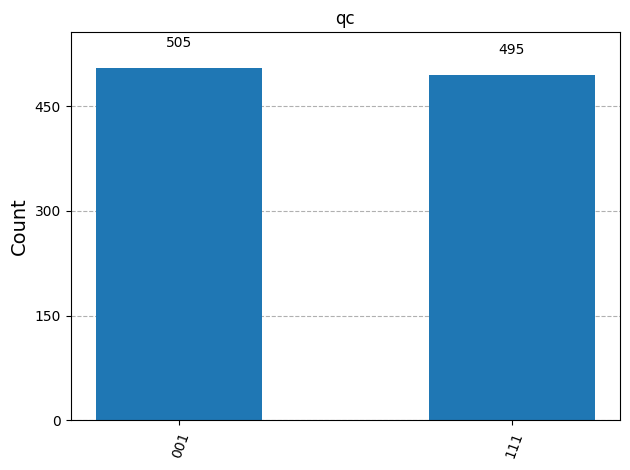

In [4]:
sim_ideal = AerSimulator()
result = sim_ideal.run(transpile(qc , sim_ideal),shots=1000).result()
counts = result.get_counts(0)
print("Measurement Output:", counts)
plot_histogram(counts, title='qc')


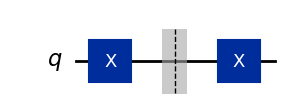

In [5]:
# barrier를 사용하는 예: 컴파일러의 최적화 범위는 barrier로 구획됩니다.

qc = QuantumCircuit(1)
qc.x(0)
qc.barrier()
qc.x(0)
qc.draw('mpl')

In [6]:
# control flow class들의 이름 보기
ctrl_flow_name_map = get_control_flow_name_mapping()
print(ctrl_flow_name_map)

{'if_else': <class 'qiskit.circuit.controlflow.if_else.IfElseOp'>, 'while_loop': <class 'qiskit.circuit.controlflow.while_loop.WhileLoopOp'>, 'for_loop': <class 'qiskit.circuit.controlflow.for_loop.ForLoopOp'>, 'switch_case': <class 'qiskit.circuit.controlflow.switch_case.SwitchCaseOp'>, 'box': <class 'qiskit.circuit.controlflow.box.BoxOp'>}


control flow와 dynamic timing을 사용한 고급회로:


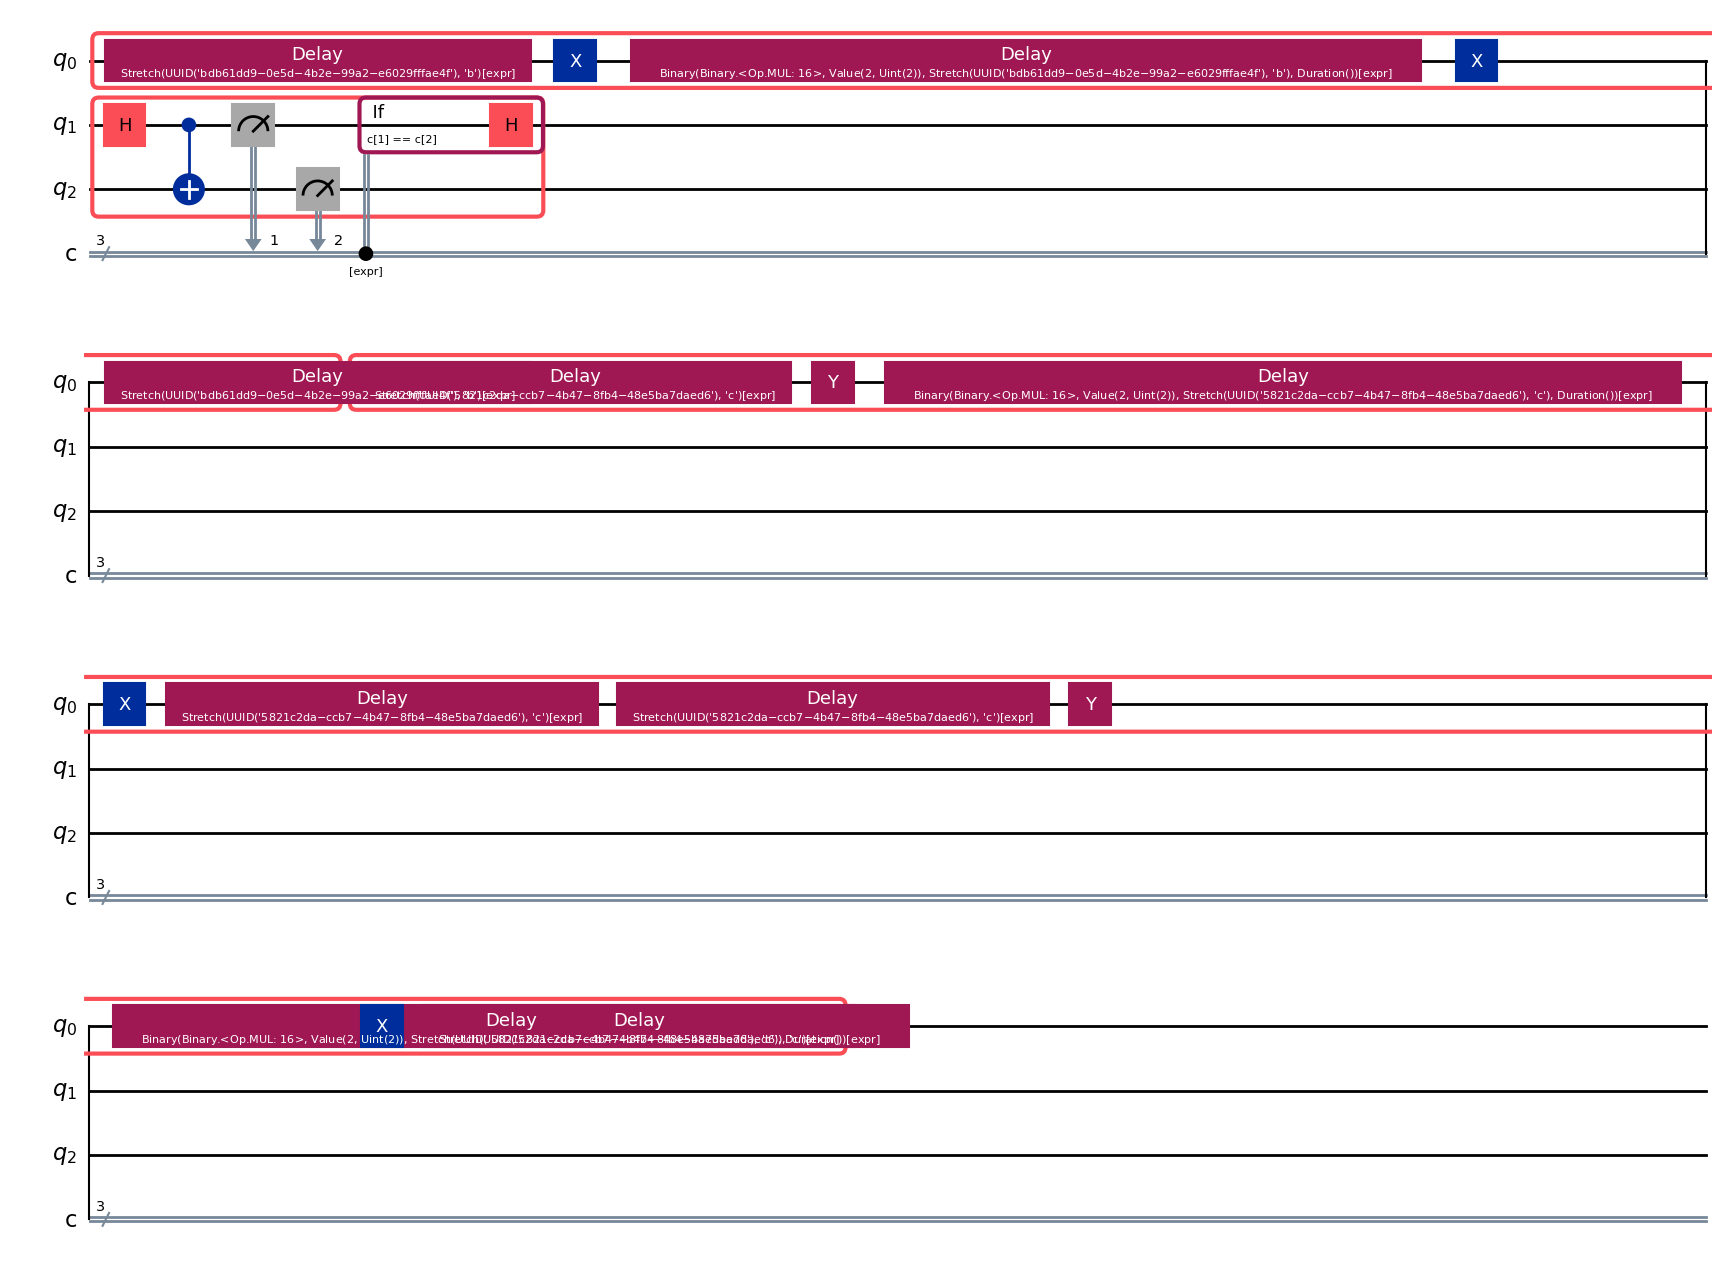

In [7]:
# 가변적인 delay와 control flow를 사용하는 예

qc = QuantumCircuit(3, 3)
# `add_stretch`는, 정해진 시간만큼 delay 시키는 것이 아니고, compile-time에 얼마만큼 delay할 것인지 결정하게 해줍니다.
a = qc.add_stretch("a")
b = qc.add_stretch("b")
c = qc.add_stretch("c")
 
# `box` context manager를 사용해서 여러 operation들을 하나의 atomic operation으로 묶을수 있습니다. 
# 아래의 예의 `box`는 시간이 얼마나 걸릴지 사전에 알 수 없는 feed-forward operation들을 포함합니다.
with qc.box():
    qc.h(1)
    qc.cx(1, 2)
    qc.measure([1, 2], [1, 2])
    with qc.if_test(expr.equal(qc.clbits[1], qc.clbits[2])):
        qc.h(1)
 
# 위의 `box`가 qubit 1, 2를 가지고 돌아가는 동안, qubit 0가 두 Dynamical Decoupling (DD) sequence를 수행하도록 
# `box` 두 개를 더 만듭니다. 두 DD sequence는 다른 stretch(b, c)를 가지고 있지만, `box`가 같은 stretch(a)로 열렸으므로 
# 길이가 같습니다.
with qc.box(duration=a):
    # Textbook NMRish XX DD.
    qc.delay(b, 0)
    qc.x(0)
    qc.delay(expr.mul(2, b), 0)
    qc.x(0)
    qc.delay(b, 0)
    
with qc.box(duration=a):
    # XY4-like DD.
    for _ in range(2):
        qc.delay(c, 0)
        qc.y(0)
        qc.delay(expr.mul(2, c), 0)
        qc.x(0)
        qc.delay(c, 0)
        
print("control flow와 dynamic timing을 사용한 고급회로:")
qc.draw('mpl')

### Instruction SubClass 만들기

Instruction이나 gate를 만드는 가장 쉬운 방법은, `QuantumCircuit`을 만든 후, `.to_instruction()`이나 `.to_gate()`를 부르는 것입니다. 결과물인 instruction이나 gate는 `QuantumCircuit.append()`에 바로 넣을 수 있습니다.

더 복잡하거나 자주 쓰일 instruction을 만들고 싶으면 사용자 정의 gate나 insturction을 만들수 있습니다. 기본 class인 `Instruction` , `Gate`, `ControlledGate`를 확장하고, `_define()` 함수를 override해서 필요한 instruction이나 gate의 정의에 맞도록 회로를 구현합니다. `inverse()`, `control()`, `power()` 등의 함수도 최적화된 형태로 override 할수 있습니다.

In [8]:
# 사용자 정의 2-qubit gate의 예

class RXZGate(Gate):
    """RZX operation을 구현한 사용자 정의 2-qubit gate"""
    
    def __init__(self, theta):
        # 이름, qubit 수, parameter로 초기화
        super().__init__("rxz", 2, [theta])
 
    def _define(self):
        # RZXGate 정의하기
        defn = QuantumCircuit(2)
        defn.rzx(self.params[0], 1, 0)  # Note: qubit 순서가 거꾸로
        self._definition = defn
 
    def inverse(self, annotated=False):
        # `Gate` class가 제공하는 것보다 더 효율적인 inverse operation을 정의할수 있으므로 override.
        return RXZGate(-self.params[0])
 
    def power(self, exponent: float):
        # 더 효율적인 power operation으로 override.
        return RXZGate(exponent * self.params[0])
 
    def __array__(self, dtype=None, copy=None):
        if copy is False:
            raise ValueError("array를 구하려면 반드시 copy 해야함")
            
        cos = math.cos(0.5 * self.params[0])
        isin = 1j * math.sin(0.5 * self.params[0])
        return np.array([
            [cos, -isin, 0, 0],
            [-isin, cos, 0, 0],
            [0, 0, cos, isin],
            [0, 0, isin, cos],
        ], dtype=dtype)

# Test
theta = Parameter("theta")
custom_gate = RXZGate(theta)
print("Custom RXZGate created successfully!")
print(f"Gate name: {custom_gate.name}")
print(f"Number of qubits: {custom_gate.num_qubits}")
print(f"Parameters: {custom_gate.params}")

Custom RXZGate created successfully!
Gate name: rxz
Number of qubits: 2
Parameters: [Parameter(theta)]


이 사용자 정의 gate를 `EquivalenceLibrary`에 등록하면 transpile에서 translate 단계가 회로를 구성요소로 분해하는 과정을 더 빨리 진행할수 있게 해줍니다.

In [10]:
theta = Parameter("theta")
 
equiv = QuantumCircuit(2)
equiv.h(0)
equiv.cx(1, 0)
equiv.rz(theta, 0)
equiv.cx(1, 0)
equiv.h(0)
 
SessionEquivalenceLibrary.add_equivalence(RXZGate(theta), equiv)

### Abstract circtuit을 physical circuit으로 바꾸기

Abstract circuit을 실제 양자 컴퓨터에서 돌리려면 **transpile()** 이나 **generate_preset_pass_manager()** 를 사용해서 physical circuit으로 compile 해야 합니다.

In [9]:
# Abstract circuit을 physical circuit으로 transpile하는 예

# 복잡한 abstract circuit을 만듭니다.
abstract_qc = QuantumCircuit(3)
abstract_qc.append(RXZGate(1.5), [0, 1])

print("Original circuit:")
print(abstract_qc)

# 시험용으로 fake backend 사용
backend = FakeTorino()

# Physical circuit으로 transpile
physical_qc = transpile(abstract_qc, backend=backend, optimization_level=1)

print("\nTranspiled circuit:")
print(physical_qc)

Original circuit:
     ┌───────────┐
q_0: ┤0          ├
     │  Rxz(1.5) │
q_1: ┤1          ├
     └───────────┘
q_2: ─────────────
                  

Transpiled circuit:
global phase: 3π/2
            ┌─────────┐┌────┐┌─────────────┐┌────┐┌─────────┐   
q_0 -> 0 ─■─┤ Rz(π/2) ├┤ √X ├┤ Rz(-1.6416) ├┤ √X ├┤ Rz(π/2) ├─■─
          │ └─────────┘└────┘└─────────────┘└────┘└─────────┘ │ 
q_1 -> 1 ─■───────────────────────────────────────────────────■─
                                                                


### 양자회로 시뮬레이트 하기

양자회로를 실제 양자 컴퓨터에서 돌리지 않고 시뮬레이트하는 여러 방법이 있습니다.

- **BasicProvider**: PC나 mac에서 돌릴수 있는 간단한 simulator.
- **StateVectorSimulator**: statevector simulation.
- **qiskit_aer**: 노이즈 모델을 갖춘 고성능 simulator.
- **StateVectorSampler**: 샘플링.
- **StateVectorEstimator**: 기대값 계산.

In [10]:
# Simulation을 위해 간단한 회로를 만듭니다.
sim_qc = QuantumCircuit(1)
sim_qc.h(0)

# Statevector simulation
statevector = Statevector(sim_qc)

sim_qc.measure_all()

# Aer simulator
aer_simulator = AerSimulator()
compiled_qc = transpile(sim_qc, aer_simulator)
result = aer_simulator.run(compiled_qc, shots=1024).result()
aer_counts = result.get_counts()

print("Simulation results:")
print(f"Counts: {aer_counts}")
print(f"Statevector: {statevector}")

Simulation results:
Counts: {'1': 508, '0': 516}
Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


### Pauli twirling을 양자회로에 적용하기

Pauli twirling은 오류를 줄이기 위한 기술로서, 계통오차를 랜덤오차로 바꾸기 위해 주어진 회로의 전후에 임의의 Pauli gate들을 적용하여 논리적으로 동등한 여러 회로를 구성한 후, 그들의 측정결과를 종합합니다.

Qiskit의 `pauli_twirl_2q_gates`는 pauli twirling을 특정 2-qubit gate에 적용해 줍니다.

In [13]:
# 2-qubit gate를 가진 회로를 만듭니다.
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.rz(np.pi/4, 0)
qc.cx(0, 1)  # This might cancel with the first CX
qc.cx(1, 2)
qc.measure([0, 1, 2], [0, 1, 2])

print("Original circuit:")
print(qc)
print(f"Original circuit depth: {qc.depth()}")
print(f"Original circuit operations: {qc.count_ops()}")

# `twirling_gate`를 지정하지 않으면 "cx", "cz", "ecr", "iswap" gate에 Pauli twirling 적용
twirled_circuit = pauli_twirl_2q_gates(qc, seed=42)
print("\nSingle twirled circuit:")
print(twirled_circuit)
print(f"Twirled circuit depth: {twirled_circuit.depth()}")
print(f"Twirled circuit operations: {twirled_circuit.count_ops()}")

Original circuit:
     ┌───┐     ┌─────────┐          ┌─┐      
q_0: ┤ H ├──■──┤ Rz(π/4) ├──■───────┤M├──────
     └───┘┌─┴─┐└─────────┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├─────■─────┤ X ├──■───╫─┤M├───
          └───┘   ┌─┴─┐   └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ─────────────┤ X ├────────┤ X ├─╫──╫─┤M├
                  └───┘        └───┘ ║  ║ └╥┘
c: 3/════════════════════════════════╩══╩══╩═
                                     0  1  2 
Original circuit depth: 6
Original circuit operations: OrderedDict({'cx': 4, 'measure': 3, 'h': 1, 'rz': 1})

Applying Pauli twirling to two-qubit gates...

Single twirled circuit:
global phase: π
     ┌───┐┌───┐     ┌───┐┌─────────┐┌───┐               ┌───┐     ┌─┐          »
q_0: ┤ H ├┤ Z ├──■──┤ Z ├┤ Rz(π/4) ├┤ Z ├────────────■──┤ I ├─────┤M├──────────»
     ├───┤└───┘┌─┴─┐├───┤└──┬───┬──┘└───┘┌───┐┌───┐┌─┴─┐├───┤┌───┐└╥┘     ┌───┐»
q_1: ┤ X ├─────┤ X ├┤ X ├───┤ Y ├─────■──┤ X ├┤ Z ├┤ X ├┤ Z ├┤ Y ├─╫───■──┤ Y ├»
     ├───┤     └───┘└───┘   └───┘   ┌─┴─┐├───┤├

---
# 정리
---

이 노트북에서는 동적 양자회로 만드는 법을 다루었습니다.

1. **Qiskit's circuit 라이브러리**는 bits, registers, circuit instructions, operations, control flows, classical expressions, parmaters의 위계구조로 되어 있습니다.
2. **양자회로**에는 실제 양자 컴퓨터에 대응되는 physical circuit과, 하드웨어에 무관한 abstract circuit이 있습니다.
3. **사용자 정의** gate와 instruction을 만들수 있습니다. 
4. BasicProvider, StateVectorSimulator, Qiskit Aer, StateVectorSampler, StateVectorEstimator와 같은 **시뮬레이션 도구**들을 지원합니다.

---

## 예제

**1) Qiskit에서 abstract circuit과 physical circuit의 주된 차이점은?**

A) Abstract circuit은 classical bit을 사용, physical circuit은 quantum bit만 사용<br/>

B) Abstract circuit은 기본 gate만을 가짐, physical circuit은 사용자 정의 gate도 가짐<br/>

C) Abstract circuit은 시뮬레이션에서만 사용될수 있음, physical circuit은 실제 양자 컴퓨터에서 작동함<br/>

D) Abstract circuit은 virtual qubit으로 구성되어 하드웨어에 무관함, physical circuit은 특정 양자 컴퓨터에 연동됨<br/>

E) Abstract circuit은 빠름, physical circuit은 느림<br/>


**Answer:**
<details> <br/>

D) Abstract circuit은 virtual qubit과 상위 operation들로 정의되어 실제 어떤 하드웨어가 사용되는지와는 무관합니다. Physical circuit은 특정 백엔드(양자 컴퓨터)에서 실제로 구현된 qubit과 그 백엔드가 지원하는 operaion들만으로 정의됩니다.
</details>

---

**2) 다음 코드를 실행한 결과는?**

`qr = QuantumRegister(3, "a")`

`qc1 = QuantumCircuit(qr)`

`qc1.x(0)`

`qc1.x(2)`

`qc2 = QuantumCircuit(3)`

`qc2.h(1)`

`qc3 = qc1.compose(qc2, qubits=[0,1,2], inplace=False)`

A) qc2의 operation들만 qubit=[0, 1, 2]에 적용되는 회로<br/>

B) qc1은 버리고 qubit들이 재정렬되는 회로<br/>

C) qc1이 먼저 적용되고 qc2가 같은 physical qubit들에 적용되는 회로<br/>

D) H gate가 X gate들을 덮어쓰는 회로<br/>


**Answer:**
<details> <br/>

C)<br/>

변형으로 코드 빈칸/빈줄 채우기 문제도 가능
</details>

---

**3) Pauli twirling을 주어진 회로의 특정 2-qubit gate에 적용하려면 어떤 Qiskit 함수를 써야하나?**

A) pauli_twirl_2q_gates()

B) apply_pauli_twirl()

C) pauli_twirl()

D) twirl_two_qubit_gates()

E) randomize_pauli_gates()

**Answer:**
<details> <br/>

A)

</details>